In [46]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression, LinearRegression
from xgboost import XGBClassifier, XGBRegressor
import joblib

# Métricas
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix
from sklearn.metrics import mean_absolute_error, r2_score

In [47]:
def specificity_score(y_true, y_pred):
    """Calcula a Especificidade a partir da matriz de confusão."""
    # tn, fp, fn, tp
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    specificity = tn / (tn + fp)
    return specificity

def plot_confusion_matrix(y_true, y_pred, title, filename):
    """Plota e salva a matriz de confusão."""
    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['NonDemented', 'Demented'],
                yticklabels=['NonDemented', 'Demented'])
    plt.title(title)
    plt.ylabel('Verdadeiro (Actual)')
    plt.xlabel('Predito (Predicted)')
    plt.savefig(f"{filename}.png")
    print(f"Matriz de confusão salva em {filename}.png")

def plot_age_scatterplot(y_true, y_pred, title, filename):
    """Plota e salva o scatterplot de predição de idade."""
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6, s=100)
    # Linha de predição perfeita
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    plt.title(title)
    plt.xlabel('Idade Real (Actual Age)')
    plt.ylabel('Idade Predita (Predicted Age)')
    plt.grid(True)
    plt.savefig(f"{filename}.png")
    print(f"Gráfico de predição de idade salvo em {filename}.png")

def load_data_set(set_name):
    """
    Carrega apenas o features_full.csv (Age + Ventricle) e o 'Group' limpo.
    """
    base_dir = f'../database/{set_name}'
    try:
        # Carrega apenas o features_full, que agora é o arquivo mestre
        data = pd.read_csv(os.path.join(base_dir, 'features_full.csv'), sep=';', decimal=',')
        
        # Cria 'Group_num' (necessário para o target y)
        # O 'Group' já vem limpo como 'Demented' ou 'NonDemented'
        data['Group_num'] = data['Group'].map({'NonDemented': 0, 'Demented': 1})
        
        # Remove linhas onde o target (Group_num) ou a feature (Age) são nulos
        data = data.dropna(subset=['Group_num', 'Age'])
        
        return data
    except FileNotFoundError as e:
        print(f"Erro ao carregar features_full.csv de '{set_name}': {e}")
        return None
    except Exception as e:
        print(f"Erro ao processar dados de '{set_name}': {e}")
        return None

In [48]:
# Carrega os três conjuntos de dados
df_train = load_data_set('treino')
df_val = load_data_set('validacao')
df_test = load_data_set('teste')

if df_train is None or df_val is None or df_test is None:
    print("Falha no carregamento dos dados. Verifique os caminhos e os arquivos.")
else:
    print(f"Dados carregados: Treino({df_train.shape}), Validação({df_val.shape}), Teste({df_test.shape})")
    print(f"Colunas disponíveis: {df_train.columns.tolist()}")

Dados carregados: Treino((239, 11)), Validação((58, 11)), Teste((76, 11))
Colunas disponíveis: ['Subject ID', 'MRI ID', 'Group', 'Age', 'Ventricle_Area', 'Ventricle_Perimeter', 'Ventricle_Circularity', 'Ventricle_Eccentricity', 'Ventricle_Solidity', 'Ventricle_MajorAxisLength', 'Group_num']


Classificação (Demented vs NonDemented)

--- Treinando Modelo: Regressão Linear ---
Modelo de Regressão Logística treinado.
Modelo (LR Demência) salvo com sucesso em: models/modelo_lr_demencia.joblib

--- Métricas (Regressão Linear) no Conjunto de Teste ---
Acurácia:     0.5526
Sensibilidade: 0.3611 (Recall)
Especificidade: 0.7250 (Specificity)
Matriz de confusão salva em out/cm_lr_demencia.png

--- Treinando Modelo: XGBoost Classifier ---
Avaliando XGBoost com early stopping...

--- Métricas (XGBoost Classifier) no Conjunto de Teste ---
Acurácia:     0.4737
Sensibilidade: 0.3889 (Recall)
Especificidade: 0.5500 (Specificity)
Matriz de confusão salva em out/cm_xgb_demencia.png

--- Salvando Modelo Final de Classificação (XGBoost) ---
Treinando pipeline final de XGBoost Classifier...
Modelo (XGBoost Classifier de Demência) salvo com sucesso em: models/modelo_xgb_demencia.joblib


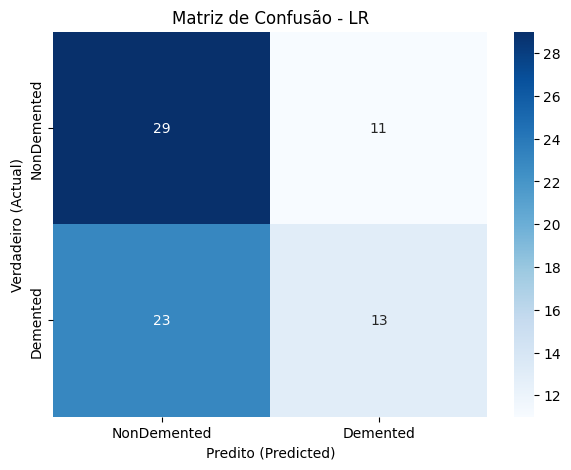

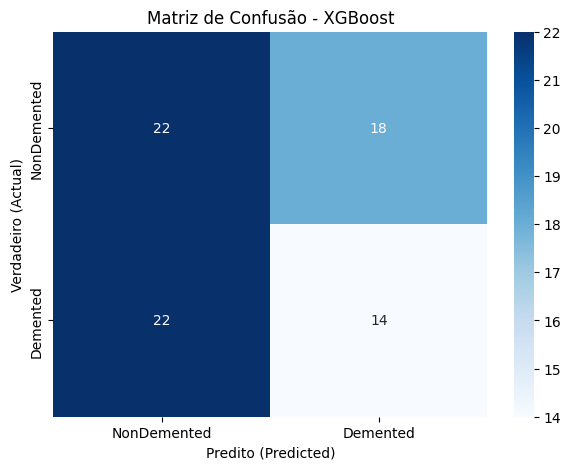

In [49]:
print("Classificação (Demented vs NonDemented)")

# Carregar dados
df_train = load_data_set('treino')
df_val = load_data_set('validacao')
df_test = load_data_set('teste')

if df_train is None or df_val is None or df_test is None:
    print("Falha no carregamento dos dados. Abortando.")
else:
    # Definir Features
    num_features_t1 = [
        'Age', 
        'Ventricle_Area', 'Ventricle_Perimeter', 'Ventricle_Circularity', 
        'Ventricle_Eccentricity', 'Ventricle_Solidity', 'Ventricle_MajorAxisLength'
    ]
    cat_features_t1 = [] 

    # Definir X e y
    target_t1 = 'Group_num'
    
    X_train = df_train[num_features_t1]
    y_train = df_train[target_t1]
    
    X_val = df_val[num_features_t1]
    y_val = df_val[target_t1]
    
    X_test = df_test[num_features_t1]
    y_test = df_test[target_t1]
    
    # Juntar treino e validação para os modelos finais
    X_train_val_unprocessed = pd.concat([X_train, X_val])
    y_train_val_unprocessed = pd.concat([y_train, y_val])

    # Criar Pipeline de Pré-processamento
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_features_t1)
        ],
        remainder='drop' 
    )

    # Modelo 1: Regressão Logística (Linear)
    print("\n--- Treinando Modelo: Regressão Linear ---")
    
    pipeline_lr = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(C=0.01, random_state=42, max_iter=1000, solver='liblinear')) 
    ])
    
    # Treina o modelo final (Treino+Validação)
    pipeline_lr.fit(X_train_val_unprocessed, y_train_val_unprocessed)
    print("Modelo de Regressão Logística treinado.")
    
    # Salvar o Modelo LR
    MODEL_LR_PATH = 'models/modelo_lr_demencia.joblib'
    try:
        os.makedirs('models', exist_ok=True)
        joblib.dump(pipeline_lr, MODEL_LR_PATH)
        print(f"Modelo (LR Demência) salvo com sucesso em: {MODEL_LR_PATH}")
    except Exception as e:
        print(f"Erro ao salvar o modelo LR: {e}")

    # Avaliar LR no Teste
    y_pred_lr_t1 = pipeline_lr.predict(X_test)
    
    print("\n--- Métricas (Regressão Linear) no Conjunto de Teste ---")
    print(f"Acurácia:     {accuracy_score(y_test, y_pred_lr_t1):.4f}")
    print(f"Sensibilidade: {recall_score(y_test, y_pred_lr_t1):.4f} (Recall)")
    print(f"Especificidade: {specificity_score(y_test, y_pred_lr_t1):.4f} (Specificity)")
    plot_confusion_matrix(y_test, y_pred_lr_t1, "Matriz de Confusão - LR", "out/cm_lr_demencia")

    # Modelo 2: XGBoost Classifier
    print("\n--- Treinando Modelo: XGBoost Classifier ---")

    print("Avaliando XGBoost com early stopping...")
    X_train_processed = preprocessor.fit_transform(X_train)
    y_train_processed = y_train
    
    X_val_processed = preprocessor.transform(X_val)
    y_val_processed = y_val

    model_xgb_c_eval = XGBClassifier(random_state=42, eval_metric='logloss', early_stopping_rounds=10)
    model_xgb_c_eval.fit(X_train_processed, y_train_processed,
                    eval_set=[(X_val_processed, y_val_processed)],
                    verbose=False)

    X_test_processed = preprocessor.transform(X_test)
    y_pred_xgb_t1 = model_xgb_c_eval.predict(X_test_processed)
    
    print("\n--- Métricas (XGBoost Classifier) no Conjunto de Teste ---")
    print(f"Acurácia:     {accuracy_score(y_test, y_pred_xgb_t1):.4f}")
    print(f"Sensibilidade: {recall_score(y_test, y_pred_xgb_t1):.4f} (Recall)")
    print(f"Especificidade: {specificity_score(y_test, y_pred_xgb_t1):.4f} (Specificity)")
    plot_confusion_matrix(y_test, y_pred_xgb_t1, "Matriz de Confusão - XGBoost", "out/cm_xgb_demencia")

    # 7. Treinar e Salvar o Pipeline Final do XGBoost
    print("\n--- Salvando Modelo Final de Classificação (XGBoost) ---")
    
    pipeline_xgb_c_final = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(random_state=42, eval_metric='logloss')) # Sem early stopping
    ])
    
    try:
        print("Treinando pipeline final de XGBoost Classifier...")
        pipeline_xgb_c_final.fit(X_train_val_unprocessed, y_train_val_unprocessed) 
        MODEL_XGB_C_PATH = 'models/modelo_xgb_demencia.joblib'
        joblib.dump(pipeline_xgb_c_final, MODEL_XGB_C_PATH)
        print(f"Modelo (XGBoost Classifier de Demência) salvo com sucesso em: {MODEL_XGB_C_PATH}")
    
    except Exception as e:
        print(f"Erro ao salvar o modelo XGBoost: {e}")

Regressão (Estimar Idade)

--- Treinando Modelo: Regressão Linear ---

--- Métricas (Regressão Linear) no Conjunto de Teste ---
R² Score: -0.1029
MAE (Erro Médio Absoluto): 6.2156 anos
Gráfico de predição de idade salvo em out/scatter_lr_age.png

--- Treinando Modelo: XGBoost Regressor ---

--- Métricas (XGBoost Regressor) no Conjunto de Teste ---
R² Score: 0.0900
MAE (Erro Médio Absoluto): 5.5818 anos
Gráfico de predição de idade salvo em out/scatter_xgb_age.png

--- Salvando Modelos Finais de Regressão de Idade (Pipelines) ---
Treinando pipeline final de Regressão Linear de Idade...
Modelo (Regressão Linear de Idade) salvo com sucesso em: models/modelo_lr_idade.joblib
Treinando pipeline final de XGBoost Regressor de Idade...
Modelo (XGBoost Regressor de Idade) salvo com sucesso em: models/modelo_xgb_idade.joblib


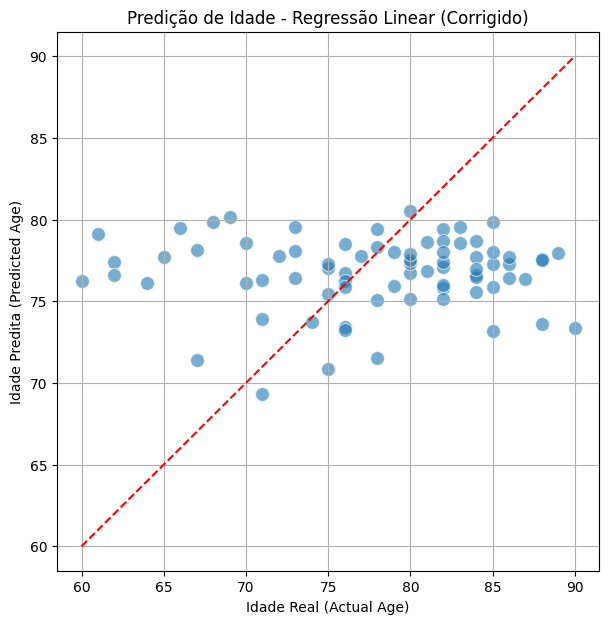

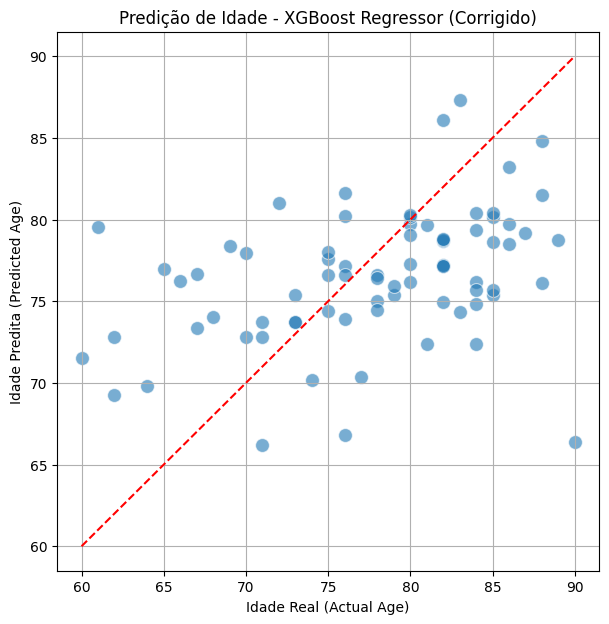

In [50]:
print("Regressão (Estimar Idade)")

# 1. Definir Target (y)
target_t2 = 'Age'

# 2. Definir Features (X)
cat_features_t2 = []
num_features_t2 = [
    'Group_num', 
    'Ventricle_Area', 'Ventricle_Perimeter', 'Ventricle_Circularity', 
    'Ventricle_Eccentricity', 'Ventricle_Solidity', 'Ventricle_MajorAxisLength'
]

# 3. Criar Pipeline de Pré-processamento
preprocessor_t2 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features_t2) 
    ],
    remainder='drop'
)

# 4. Preparar X e y
X_train_t2_processed = preprocessor_t2.fit_transform(df_train)
y_train_t2 = df_train[target_t2]

X_val_t2_processed = preprocessor_t2.transform(df_val)
y_val_t2 = df_val[target_t2]

X_test_t2_processed = preprocessor_t2.transform(df_test)
y_test_t2 = df_test[target_t2]

# 5. Modelo 1: Regressão Linear
print("\n--- Treinando Modelo: Regressão Linear ---")
model_lr_r_eval = LinearRegression()
model_lr_r_eval.fit(X_train_t2_processed, y_train_t2)
y_pred_lr_t2 = model_lr_r_eval.predict(X_test_t2_processed)

print("\n--- Métricas (Regressão Linear) no Conjunto de Teste ---")
print(f"R² Score: {r2_score(y_test_t2, y_pred_lr_t2):.4f}")
print(f"MAE (Erro Médio Absoluto): {mean_absolute_error(y_test_t2, y_pred_lr_t2):.4f} anos")
plot_age_scatterplot(y_test_t2, y_pred_lr_t2, "Predição de Idade - Regressão Linear (Corrigido)", "out/scatter_lr_age")

# 6. Modelo 2: XGBoost Regressor (Para Avaliação)
print("\n--- Treinando Modelo: XGBoost Regressor ---")
model_xgb_r_eval = XGBRegressor(random_state=42, eval_metric='rmse', early_stopping_rounds=10)
model_xgb_r_eval.fit(X_train_t2_processed, y_train_t2,
                eval_set=[(X_val_t2_processed, y_val_t2)],
                verbose=False)

y_pred_xgb_t2 = model_xgb_r_eval.predict(X_test_t2_processed)
print("\n--- Métricas (XGBoost Regressor) no Conjunto de Teste ---")
print(f"R² Score: {r2_score(y_test_t2, y_pred_xgb_t2):.4f}")
print(f"MAE (Erro Médio Absoluto): {mean_absolute_error(y_test_t2, y_pred_xgb_t2):.4f} anos")
plot_age_scatterplot(y_test_t2, y_pred_xgb_t2, "Predição de Idade - XGBoost Regressor (Corrigido)", "out/scatter_xgb_age")

print("\n--- Salvando Modelos Finais de Regressão de Idade (Pipelines) ---")

# 7. Preparar dados de Treino+Validação 
X_train_val_t2_unprocessed = pd.concat([
    df_train[num_features_t2 + cat_features_t2],
    df_val[num_features_t2 + cat_features_t2]
])
y_train_val_t2_unprocessed = pd.concat([
    df_train[target_t2],
    df_val[target_t2]
])

# 8. Pipeline 1 (Regressão Linear)
pipeline_lr_r = Pipeline(steps=[
    ('preprocessor', preprocessor_t2),
    ('regressor', LinearRegression())
])

# 9. Pipeline 2 (XGBoost Regressor)
pipeline_xgb_r = Pipeline(steps=[
    ('preprocessor', preprocessor_t2),
    ('regressor', XGBRegressor(random_state=42, eval_metric='rmse')) # Sem early stopping
])

# 10. Treinar e Salvar os Pipelines
try:
    # Modelo Linear
    print("Treinando pipeline final de Regressão Linear de Idade...")
    pipeline_lr_r.fit(X_train_val_t2_unprocessed, y_train_val_t2_unprocessed)
    MODEL_LR_R_PATH = 'models/modelo_lr_idade.joblib'
    joblib.dump(pipeline_lr_r, MODEL_LR_R_PATH)
    print(f"Modelo (Regressão Linear de Idade) salvo com sucesso em: {MODEL_LR_R_PATH}")
    
    # Modelo XGBoost
    print("Treinando pipeline final de XGBoost Regressor de Idade...")
    pipeline_xgb_r.fit(X_train_val_t2_unprocessed, y_train_val_t2_unprocessed)
    MODEL_XGB_R_PATH = 'models/modelo_xgb_idade.joblib'
    joblib.dump(pipeline_xgb_r, MODEL_XGB_R_PATH)
    print(f"Modelo (XGBoost Regressor de Idade) salvo com sucesso em: {MODEL_XGB_R_PATH}")
    
except Exception as e:
    print(f"Erro ao salvar os modelos de idade: {e}")